# 01 — Exploratory data analysis

**Dataset:** Medical Cost Personal Dataset (Kaggle, 1,338 rows). **Target:** `charges`, annual medical charges in USD — *not* an insurance premium.

All observations in this notebook are **exploratory** and describe associations in this dataset only; none are causal claims or final model results. Reusable code lives in `src/insurance_cost/`; this notebook only calls it and writes figures to `reports/figures/`.

In [1]:
import json
from IPython.display import Image, display

from insurance_cost.config import DATA_PATH, FIGURES_DIR
from insurance_cost.data import load_dataset, validation_summary
from insurance_cost.evaluate import save_eda_figures

df = load_dataset(DATA_PATH)
print(json.dumps(validation_summary(df), indent=1))

{
 "rows": 1338,
 "dtypes": {
  "age": "int64",
  "sex": "str",
  "bmi": "float64",
  "children": "int64",
  "smoker": "str",
  "region": "str",
  "charges": "float64"
 },
 "missing": {
  "age": 0,
  "sex": 0,
  "bmi": 0,
  "children": 0,
  "smoker": 0,
  "region": 0,
  "charges": 0
 },
 "duplicate_rows": 1,
 "numeric_ranges": {
  "age": {
   "min": 18.0,
   "max": 64.0
  },
  "bmi": {
   "min": 15.96,
   "max": 53.13
  },
  "children": {
   "min": 0.0,
   "max": 5.0
  },
  "charges": {
   "min": 1121.8739,
   "max": 63770.42801
  }
 },
 "category_levels": {
  "sex": {
   "female": 662,
   "male": 676
  },
  "smoker": {
   "no": 1064,
   "yes": 274
  },
  "region": {
   "northeast": 324,
   "northwest": 325,
   "southeast": 364,
   "southwest": 325
  }
 }
}


## Data quality

- 1,338 rows, 7 columns, **no missing values**, all categories within the expected levels.
- **One exact duplicate row.** With no ID column it cannot be shown to be an error (two people can share these values), so it is kept and reported (documented policy in `insurance_cost.data`).
- Observed ranges: age 18–64, BMI 15.96–53.13 kg/m², children 0–5, charges \$1,122–\$63,770. The app restricts inputs to the training ranges because the model has not seen anything outside them.

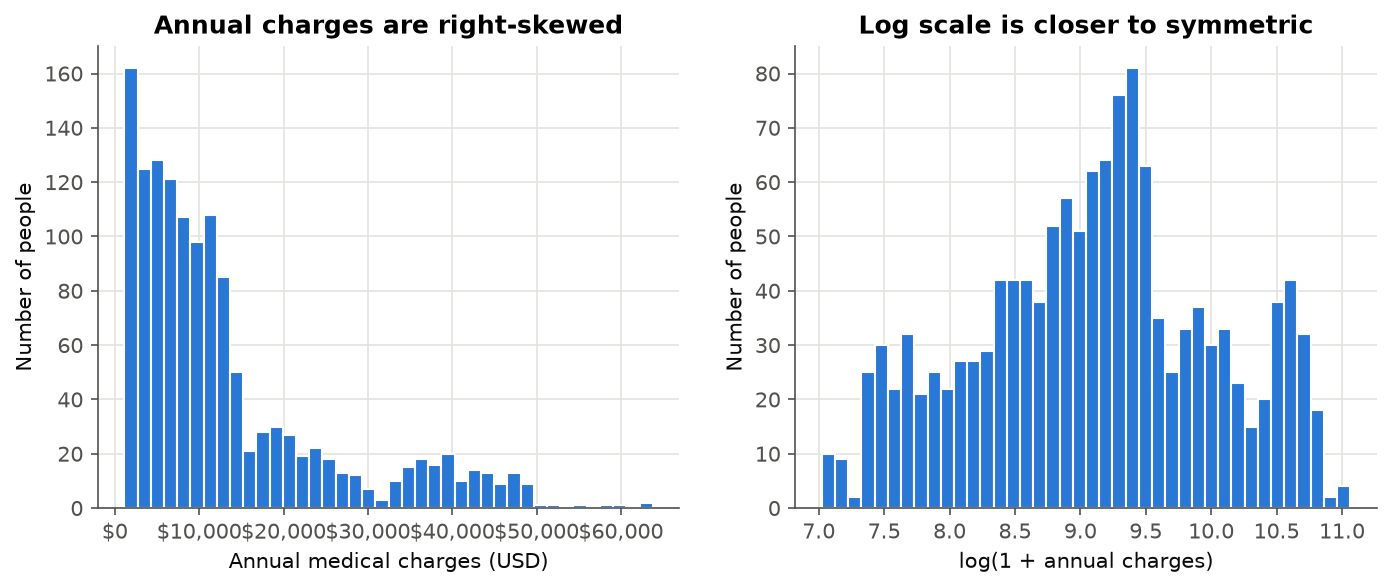

In [2]:
paths = {p.stem: p for p in save_eda_figures(df, FIGURES_DIR)}
display(Image(paths["eda_target_distribution"]))

## Target distribution *(exploratory)*

Charges are strongly right-skewed: mean \$13,270 vs median \$9,382 (skew 1.52). A small number of very expensive people pull the mean up. On the `log1p` scale the distribution is roughly symmetric (skew −0.09), which is why the modelling stage compares a raw-dollar target with a log target. Either way, metrics are reported in dollars.

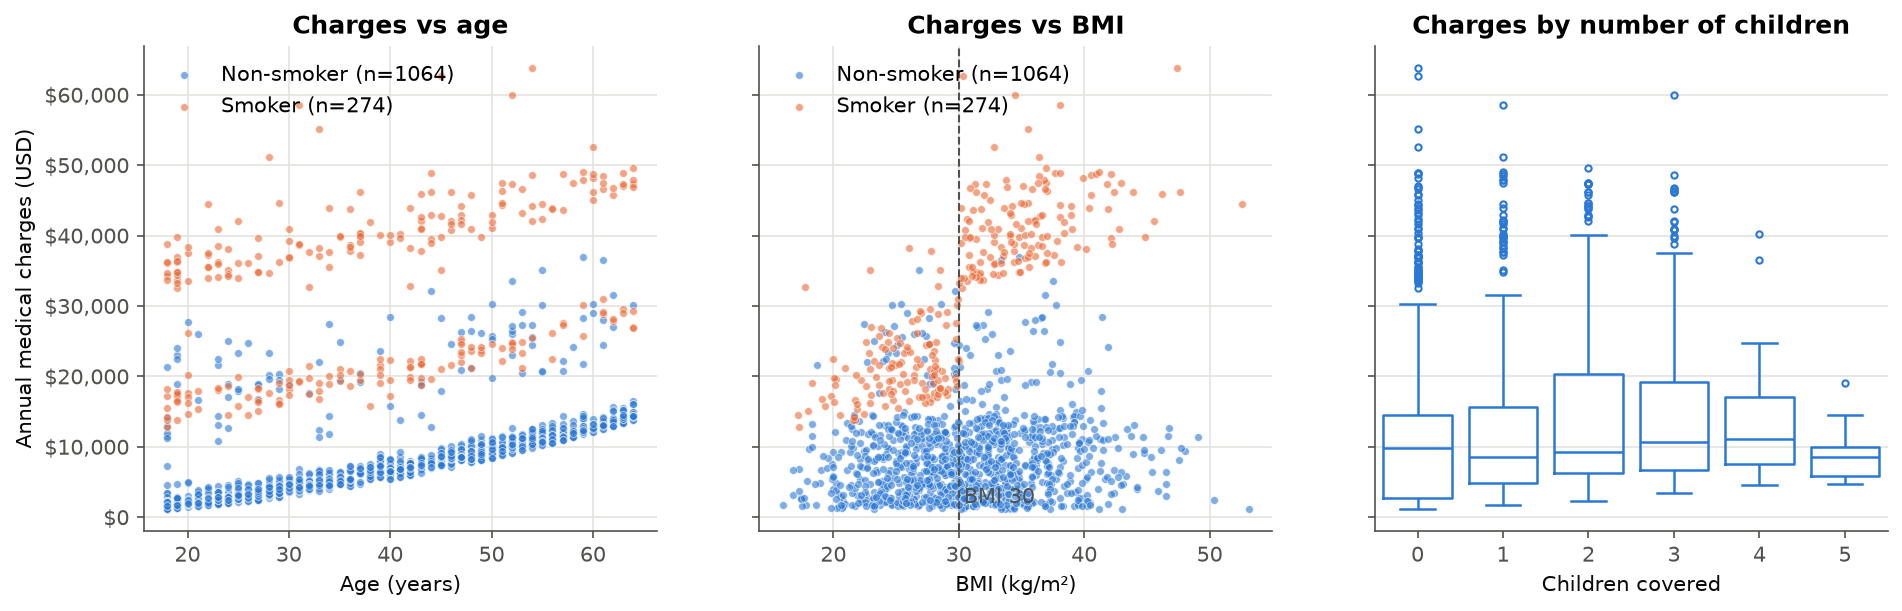

In [3]:
display(Image(paths["eda_numeric_relationships"]))

## Charges vs age, BMI and children *(exploratory)*

- **Age:** charges rise steadily with age in every group. There are three visible bands: most non-smokers sit in the lowest band, smokers in the upper two, and a middle band mixes smokers with about 94 of 1,064 non-smokers who sit more than \$5k above the non-smoker age trend. That middle band suggests something that isn't in the data (e.g. a health condition), so some error is irreducible with these six features.
- **BMI:** for non-smokers, BMI has little visible association with charges. For smokers there is a clear jump around **BMI 30** (the conventional obesity threshold).
- **Children:** weak association; groups with 4–5 children are small (25 and 18 rows), so their medians are noisy.

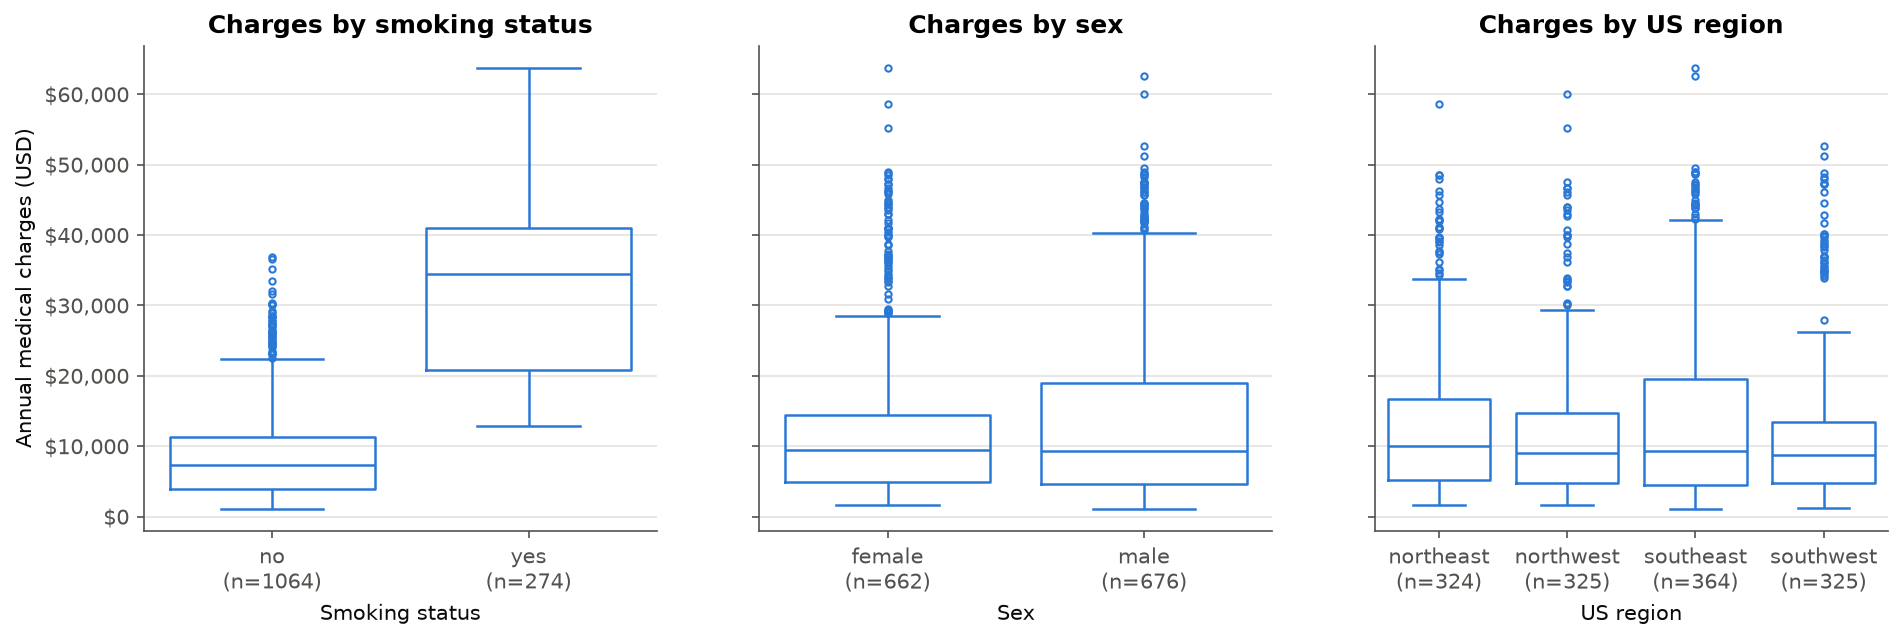

In [4]:
display(Image(paths["eda_categorical_groups"]))

## Charges by smoking status, sex and region *(exploratory)*

- **Smoking status** is the largest difference in the data: median \$34,456 for smokers vs \$7,345 for non-smokers (n = 274 vs 1,064).
- **Sex:** medians are almost identical (\$9,413 female, \$9,370 male). The higher male *mean* is at least partly because a larger share of men smoke in this sample (23.5% vs 17.4%). Sex is a weak, possibly confounded signal; the modelling stage compares a model without it.
- **Region:** small differences. The southeast has the highest mean charges, along with the highest average BMI (33.4) and smoking rate (25%), so region may partly stand in for those variables. It should not be read as a regional risk.

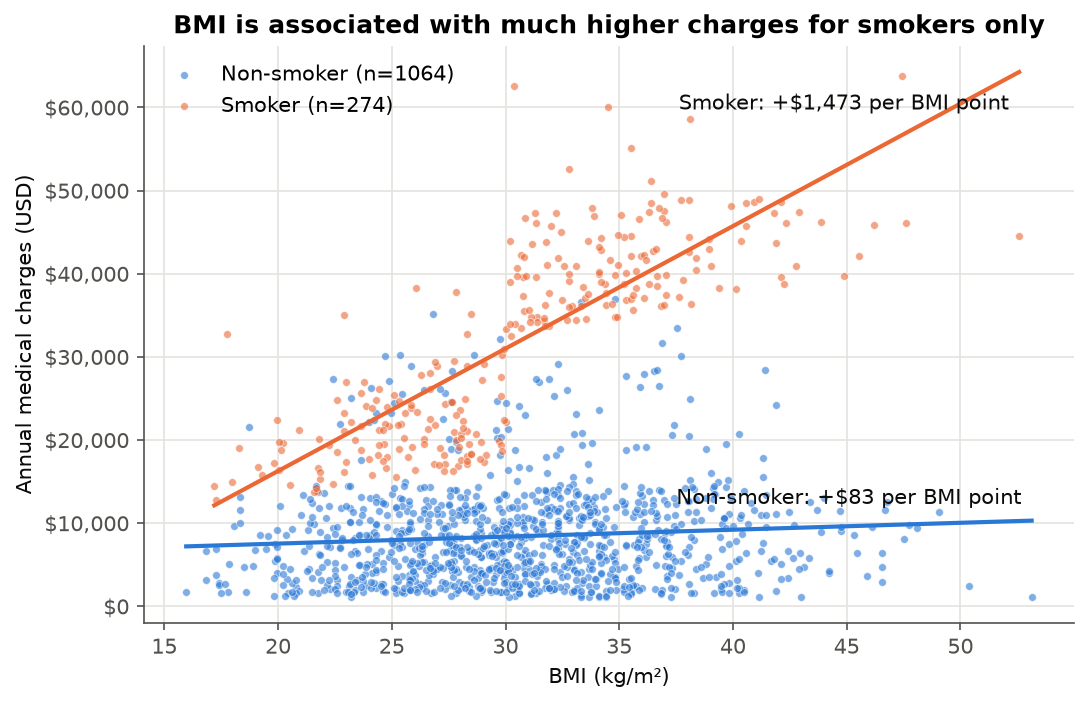

In [5]:
display(Image(paths["eda_bmi_by_smoker"]))

## The key interaction: BMI × smoking *(exploratory)*

A simple straight-line fit within each group gives about **+\$1,473 per BMI point for smokers** vs **+\$83 for non-smokers**. The BMI–charges relationship depends on smoking status, which is exactly what a `smoker × BMI` interaction term represents. A model with only additive main effects would give everyone the same BMI slope, which would be too steep for non-smokers and far too shallow for smokers.

Splitting by the BMI-30 threshold makes the same point: median charges are \$20,167 for smokers with BMI < 30 vs \$40,904 for smokers with BMI ≥ 30. For non-smokers the medians are \$6,762 vs \$8,076. The smoker pattern looks more like a step at 30 than a straight line, which the residual diagnostics should show.

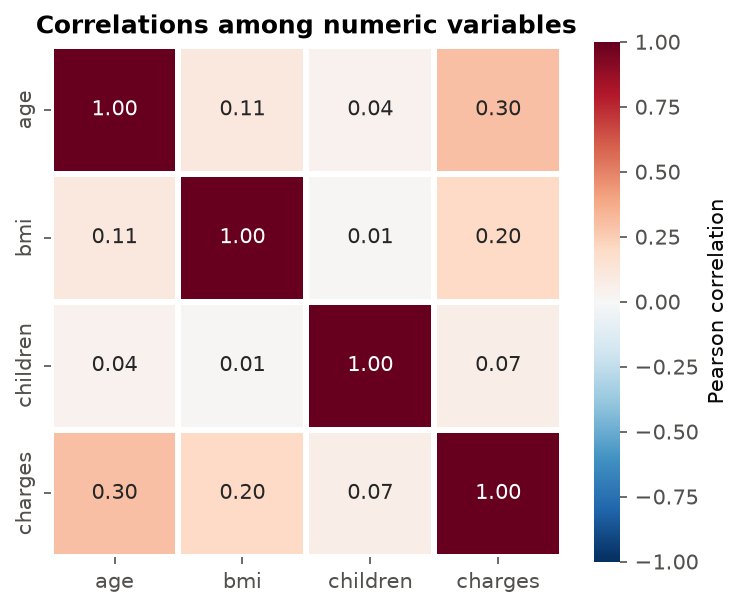

In [6]:
display(Image(paths["eda_correlations"]))

## Correlations *(exploratory)*

Pairwise linear correlations with charges are modest: age 0.30, BMI 0.20, children 0.07. The modest BMI correlation **hides** a strong relationship within smokers: averaging over everyone dilutes it. This is why a correlation matrix alone is a poor guide to feature importance when interactions exist. The numeric predictors are nearly uncorrelated with each other (≤ 0.11), so multicollinearity among main effects is not a concern.

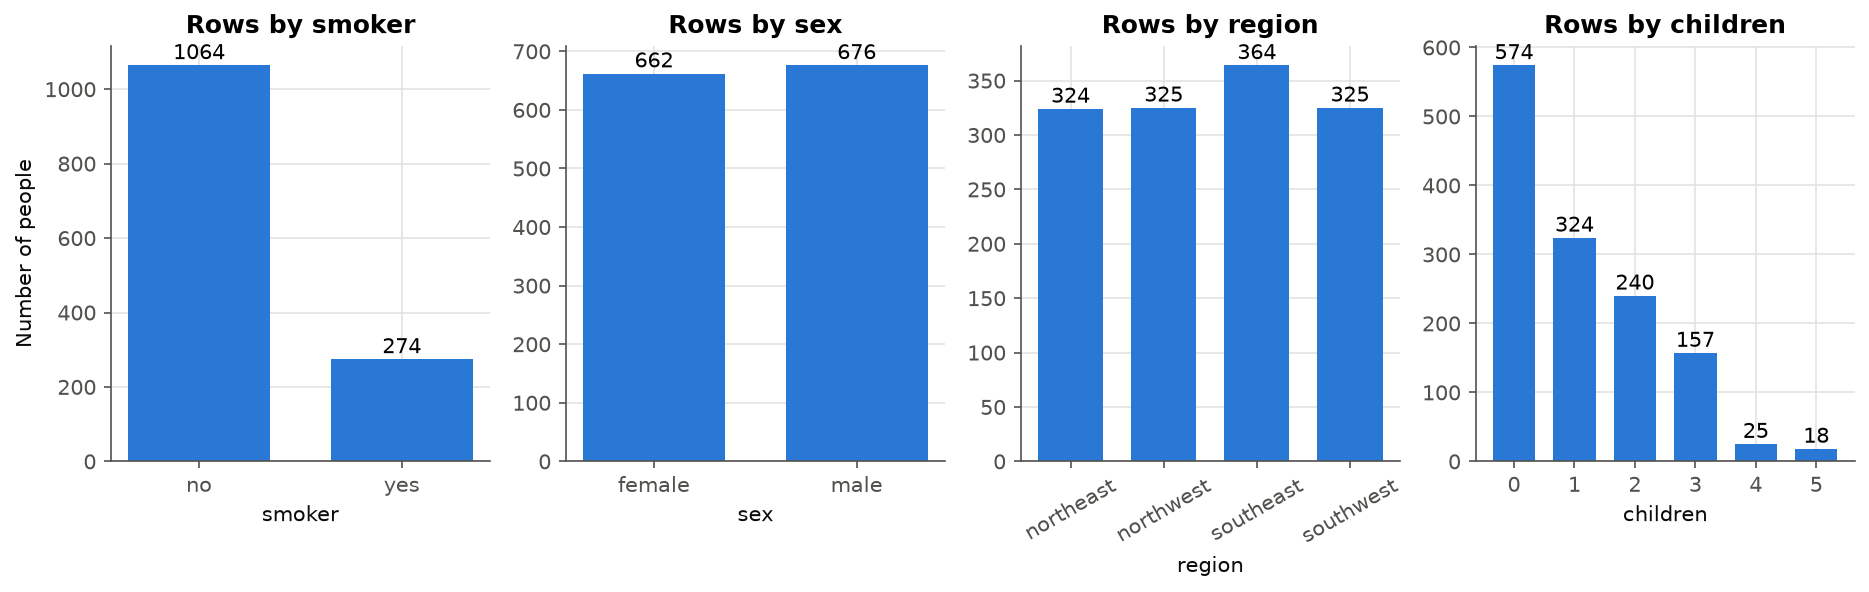

In [7]:
display(Image(paths["eda_group_counts"]))

## Group sizes *(exploratory)*

Sex and region are balanced. Smokers are about 20% of rows (274), enough for a separate slope but they deserve their own error reporting. Rows with 4–5 children are rare, so the model's behaviour there rests on very few examples.

## What this means for modelling

1. Compare a raw-dollar target with a `log1p` target because of the skew.
2. Include `smoker × BMI` and `smoker × age` interactions (keeping main effects) plus `age²`.
3. Expect large residuals from the unexplained middle band, and check whether a linear `smoker × BMI` term captures the BMI-30 step.
4. Report errors separately for smokers vs non-smokers and by sex/region, and compare a model without `sex`.